In [6]:
# ===== Standard libraries =====
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# ===== Audio =====
import librosa

# ===== PyTorch =====
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ===== Utilities =====
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from multiprocessing import Pool
from IPython.display import clear_output


import pandas as pd

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

# ===== Google Drive =====
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
data_path = '/content/drive/MyDrive/SPP_Jan_2023/data/'
!ls /content/drive/MyDrive/SPP_Jan_2023/data


noise  speech  SPP_Jan_2023


In [8]:
def get_files(subdir):
    data = os.path.join(data_path, subdir)
    assert os.path.exists(data), f"Directory not found: {data}"

    files = sorted([
        os.path.join(data, f)
        for f in os.listdir(data)
        if f.lower().endswith(('.wav', '.flac', '.mp3'))
    ])

    print(f'{len(files)} files found in {subdir}')
    return files


noise_files  = get_files('noise')
speech_files = get_files('speech')


118 files found in noise
119 files found in speech


100%|██████████| 118/118 [00:02<00:00, 41.62it/s]


Total duration: 66.72 minutes
Mean duration : 33.93 seconds


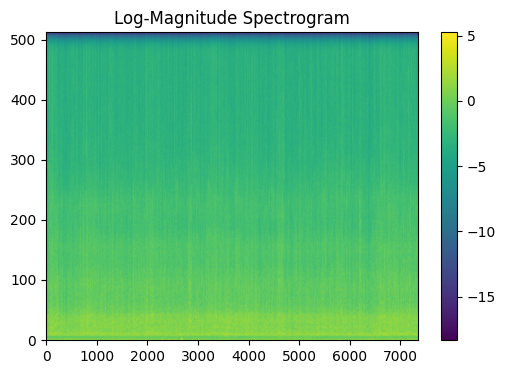

100%|██████████| 119/119 [00:00<00:00, 160.87it/s]


Total duration: 27.31 minutes
Mean duration : 13.77 seconds


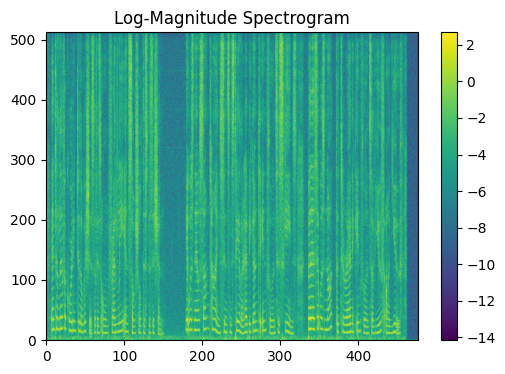

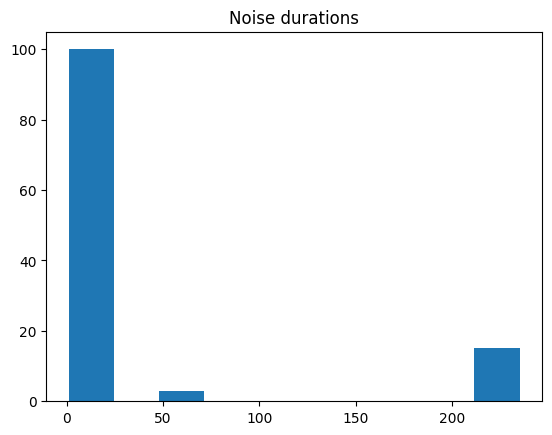

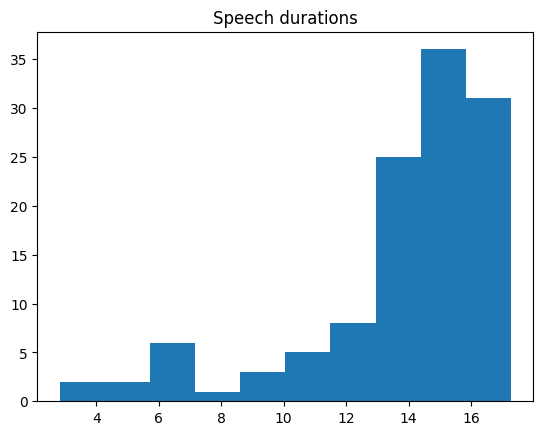

(2.833, 17.270125, 0.9259375, 235.2304375)

In [9]:
def get_dur(filename, sr=16000):
    y, _ = librosa.load(filename, sr=sr)
    return len(y) / sr


def read_audio(paths, sr=16000, num_jobs=4, plot_spec=True,
               n_fft=1024, hop_length=512):

    with Pool(num_jobs) as p:
        durations = list(tqdm(p.imap(get_dur, paths), total=len(paths)))

    print(f'Total duration: {round(sum(durations)/60, 2)} minutes')
    print(f'Mean duration : {round(np.mean(durations), 2)} seconds')

    if plot_spec:
        y, _ = librosa.load(paths[0], sr=sr)
        spec = np.log(np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length)) + 1e-8)
        plt.figure(figsize=(6,4))
        plt.imshow(spec, aspect='auto', origin='lower')
        plt.title('Log-Magnitude Spectrogram')
        plt.colorbar()
        plt.show()

    return durations


noise_durations  = read_audio(noise_files)
speech_durations = read_audio(speech_files)

plt.hist(noise_durations); plt.title("Noise durations"); plt.show()
plt.hist(speech_durations); plt.title("Speech durations"); plt.show()

min(speech_durations), max(speech_durations), min(noise_durations), max(noise_durations)


In [10]:
def show_spectrogram(paths,
                     idx,
                     sr=16000,
                     n_fft=1024,
                     hop_length=512,
                     cmap='magma'):

    assert idx < len(paths), f"Index {idx} out of range (max {len(paths)-1})"

    file = paths[idx]
    y, _ = librosa.load(file, sr=sr)

    spec = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
    log_spec = np.log(np.abs(spec) + 1e-8)

    plt.figure(figsize=(8, 4))
    plt.imshow(log_spec,
               aspect='auto',
               origin='lower',
               cmap=cmap)

    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Spectrogram\n{os.path.basename(file)}")
    plt.xlabel("Time frames")
    plt.ylabel("Frequency bins")
    plt.tight_layout()
    plt.show()

    print(f"File path:\n{file}")
    print(f"Duration: {round(len(y)/sr, 2)} seconds")



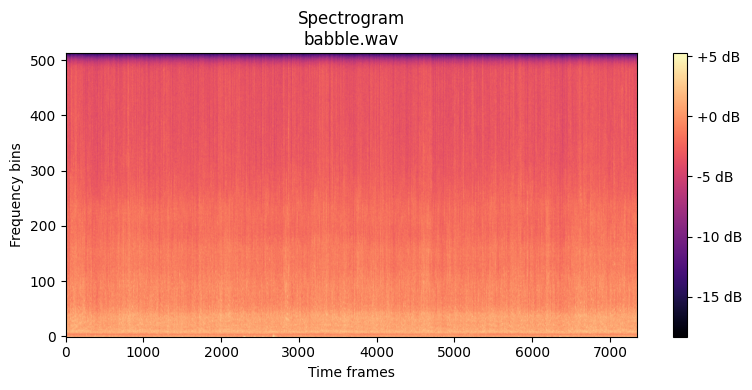

File path:
/content/drive/MyDrive/SPP_Jan_2023/data/noise/babble.wav
Duration: 235.23 seconds


In [7]:
 show_spectrogram(noise_files, idx=0)

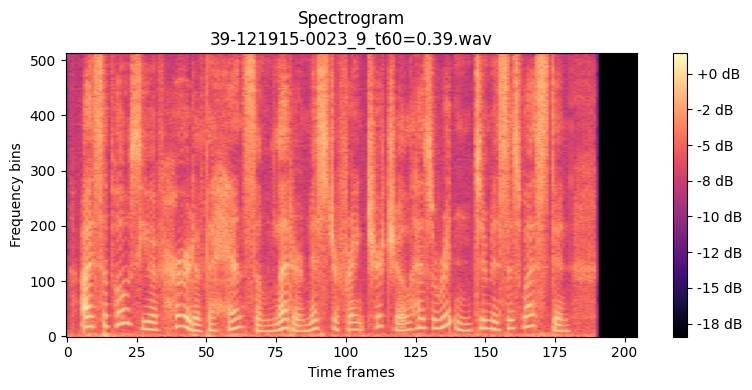

File path:
/content/drive/MyDrive/SPP_Jan_2023/data/speech/39-121915-0023_9_t60=0.39.wav
Duration: 6.55 seconds


In [8]:
show_spectrogram(speech_files, idx=9)


In [12]:
class ClassifierDataset(Dataset):
    """
    Speech vs Noise classification dataset

    label = 1 → speech
    label = 0 → noise
    """

    def __init__(self,
                 mode,
                 speech_paths,
                 noise_paths,
                 sr=16000,
                 n_fft=512,
                 hop_length=256,
                 min_wav_duration=2.0,
                 split={
                     'train': (0.0, 0.7),
                     'dev'  : (0.7, 0.85),
                     'test' : (0.85, 1.0)
                 }):

        assert mode in split, f"Invalid mode {mode}"
        self.mode = mode

        # ---------- SPLIT FILE LISTS ----------
        s0, s1 = split[mode]

        n = len(speech_paths)
        speech_paths = speech_paths[int(n*s0):int(n*s1)]

        n = len(noise_paths)
        noise_paths = noise_paths[int(n*s0):int(n*s1)]

        # ---------- STORE (file, label) ----------
        self.files = [(p, 1) for p in speech_paths] + \
                     [(p, 0) for p in noise_paths]

        if mode == 'train':
            random.shuffle(self.files)

        print(f"{mode.upper()} SET → {len(speech_paths)} speech | {len(noise_paths)} noise")

        # ---------- AUDIO PARAMS ----------
        self.sr = sr
        self.n_fft = n_fft
        self.hop = hop_length
        self.min_len = int(min_wav_duration * sr)

    def __len__(self):
        return len(self.files)

    # ---------- LOAD FIXED / RANDOM SEGMENT ----------
    def _load_segment(self, file):
        y, _ = librosa.load(file, sr=self.sr)

        if len(y) < self.min_len:
            return None

        if self.mode == 'train':
            start = random.randint(0, len(y) - self.min_len)
        else:
            start = 0  # deterministic for dev/test

        return y[start:start + self.min_len]

    def __getitem__(self, idx):
        file, label = self.files[idx]

        seg = self._load_segment(file)
        if seg is None:
            return self.__getitem__(random.randint(0, len(self)-1))

        spec = librosa.stft(seg,
                            n_fft=self.n_fft,
                            hop_length=self.hop)

        feat = np.log(np.abs(spec) + 1e-8)

        return (
            torch.from_numpy(feat).float(),   # [F, T]
            torch.tensor(label).long(),        # 0 / 1
            file                               # filepath (for inference)
        )



In [13]:
loaders = {}

for mode in ['train', 'dev', 'test']:
    dataset = ClassifierDataset(mode, speech_files, noise_files)
    loaders[mode] = DataLoader(
        dataset,
        batch_size=20,
        shuffle=(mode == 'train'),
        num_workers=2,
        pin_memory=True
    )



TRAIN SET → 83 speech | 82 noise
DEV SET → 18 speech | 18 noise
TEST SET → 18 speech | 18 noise


In [24]:
class LinearModel(nn.Module):
    def __init__(self, num_feats=257):
        super().__init__()
        self.fc = nn.Linear(num_feats, 2)

    def forward(self, x):
        x = x.mean(-1)
        return self.fc(x)


In [14]:
class NonLinearModel(nn.Module):
    def __init__(self, num_feats=257):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_feats, num_feats//2),
            nn.ReLU(),
            nn.Linear(num_feats//2, 2)
        )

    def forward(self, x):
        x = x.mean(-1)
        return self.net(x)


In [15]:
class ConvModel(nn.Module):
    def __init__(self, num_feats=257):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(num_feats, num_feats//2, kernel_size=7, stride=2),
            nn.ReLU(),
            nn.Conv1d(num_feats//2, 2, kernel_size=5, stride=2)
        )

    def forward(self, x):
        x = self.net(x)
        return x.mean(-1)


In [16]:
class LSTMModel(nn.Module):
    def __init__(self, num_feats=257, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(num_feats, hidden, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden*2, 2)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        _, (h, _) = self.lstm(x)
        h = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(h)


In [25]:
def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    losses = []
    preds = []
    labels = []

    with torch.set_grad_enabled(train):
        for x, y, _ in tqdm(loader):   # 🔑 unpack file path safely
            x = x.to(device)
            y = y.to(device)

            out = model(x)
            loss = loss_fn(out, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            losses.append(loss.item())
            preds.append(out.argmax(dim=1).cpu())
            labels.append(y.cpu())

    preds = torch.cat(preds)
    labels = torch.cat(labels)

    acc = (preds == labels).float().mean().item()
    return np.mean(losses), acc


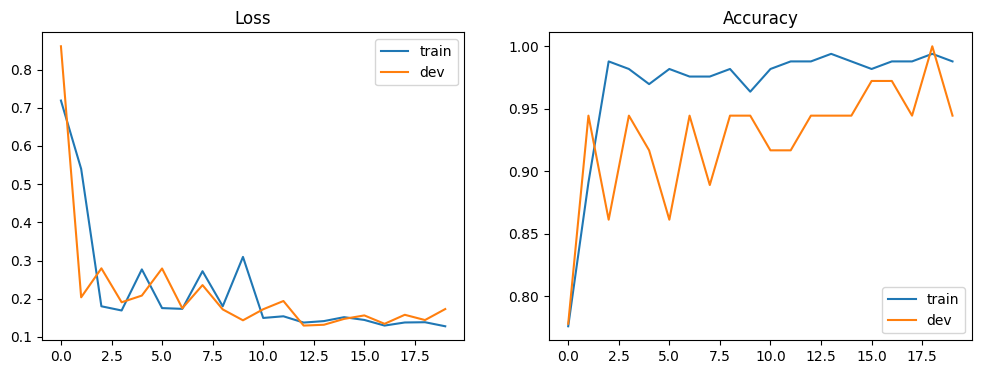

In [26]:
num_epochs = 20
tr_loss, tr_acc, dv_loss, dv_acc = [], [], [], []

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Pick one model
#model = NonLinearModel(num_feats=257).to(device)
model = LinearModel(num_feats=257).to(device)
# model = LSTMModel(num_feats=257).to(device)
# model = ConvModel(num_feats=257).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()



for epoch in range(num_epochs):
    tl, ta = run_epoch(loaders['train'], train=True)
    vl, va = run_epoch(loaders['dev'], train=False)

    tr_loss.append(tl); tr_acc.append(ta)
    dv_loss.append(vl); dv_acc.append(va)

    clear_output()
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(tr_loss, label='train')
    plt.plot(dv_loss, label='dev')
    plt.legend(); plt.title('Loss')

    plt.subplot(1,2,2)
    plt.plot(tr_acc, label='train')
    plt.plot(dv_acc, label='dev')
    plt.legend(); plt.title('Accuracy')

    plt.show()


In [27]:

"""
def evaluate(loader, device='cuda'):
    #Run model on a dataset loader and return ground-truth labels and predictions.
    model.eval()
    model.to(device)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader):
            # Handle datasets that return (x, y) or (x, y, file)
            if len(batch) == 3:
                x, y, _ = batch
            else:
                x, y = batch

            x, y = x.to(device), y.to(device)

            logits = model(x)
            preds = torch.argmax(logits, dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return all_labels, all_preds
    """


def evaluate(loader, model, device='cuda'):
    #Run model on loader and print mismatched file indices and names.

    model.eval()
    model.to(device)

    all_preds = []
    all_labels = []
    all_files = []

    with torch.no_grad():
        for batch in tqdm(loader):

            # Dataset returns (x, y, filename)
            if len(batch) == 3:
                x, y, files = batch
            else:
                raise ValueError("Dataset must return filenames to track mismatches")

            x, y = x.to(device), y.to(device)

            logits = model(x)
            preds = torch.argmax(logits, dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())
            all_files.extend(files)

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # Find mismatches
    mismatches = (all_preds != all_labels)

    print("\n Mismatched samples:")
    for idx in torch.where(mismatches)[0]:
        print(
            f"Index: {idx.item():4d} | "
            f"File: {all_files[idx]} | "
            f"True: {all_labels[idx].item()} | "
            f"Pred: {all_preds[idx].item()}"
        )

    return all_labels.numpy(), all_preds.numpy()



In [28]:
# Run inference
#test_labels, test_preds = evaluate(loaders['test'], device=device)
test_labels, test_preds = evaluate(loaders['test'], model, device=device)



100%|██████████| 2/2 [00:01<00:00,  1.57it/s]


 Mismatched samples:
Index:   20 | File: /content/drive/MyDrive/SPP_Jan_2023/data/noise/n88.wav | True: 0 | Pred: 1
Index:   32 | File: /content/drive/MyDrive/SPP_Jan_2023/data/noise/n99.wav | True: 0 | Pred: 1
Index:   34 | File: /content/drive/MyDrive/SPP_Jan_2023/data/noise/volvo.wav | True: 0 | Pred: 1


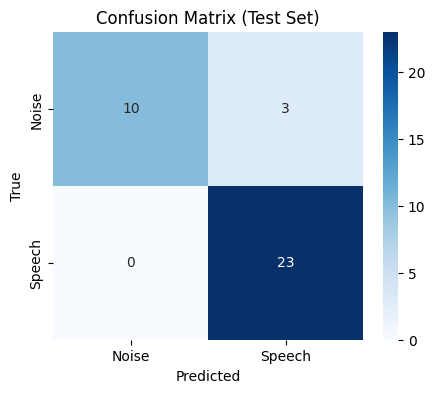

In [30]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Noise', 'Speech'],
    yticklabels=['Noise', 'Speech']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)')
plt.show()


## Precision, Recall, and F1 Score

### Binary Classification Setup

|                | Predicted Positive | Predicted Negative |
|----------------|--------------------|--------------------|
| Actual Positive | True Positive (TP) | False Negative (FN) |
| Actual Negative | False Positive (FP) | True Negative (TN) |

---

### Precision

Precision measures the accuracy of positive predictions.

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

Out of all samples predicted as positive, precision tells us what fraction is actually positive.

---

### Recall (Sensitivity)

Recall measures the ability to detect actual positives.

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

Out of all truly positive samples, recall tells us what fraction is correctly identified.

---

### F1 Score

The F1 score is the harmonic mean of precision and recall.

$$
\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

Substituting precision and recall:

$$
\text{F1} = \frac{2TP}{2TP + FP + FN}
$$

---

### Summary

$$
\begin{aligned}
\text{Precision} &= \frac{TP}{TP + FP} \\
\text{Recall} &= \frac{TP}{TP + FN} \\
\text{F1} &= \frac{2TP}{2TP + FP + FN}
\end{aligned}
$$


In [22]:
report = classification_report(
    test_labels,
    test_preds,
    target_names=['Noise', 'Speech'],
    output_dict=True
)

df = pd.DataFrame(report).T

# Keep only precision, recall, f1-score
df = df[['precision', 'recall', 'f1-score']]

print(df)



              precision    recall  f1-score
Noise          1.000000  0.823529  0.903226
Speech         0.863636  1.000000  0.926829
accuracy       0.916667  0.916667  0.916667
macro avg      0.931818  0.911765  0.915028
weighted avg   0.928030  0.916667  0.915683


In [56]:

def infer_single_file(wav_path,
                      sr=16000,
                      n_fft=512,
                      hop_length=256,
                      min_duration=2.0):
    """
    Infer whether a single audio file is Speech or Noise.

    Args:
        wav_path (str): Path to the WAV file.
        sr (int): Sampling rate.
        n_fft (int): FFT size for STFT.
        hop_length (int): Hop length for STFT.
        min_duration (float): Minimum duration in seconds.

    Returns:
        label (str): 'Speech' or 'Noise'.
        confidence (float): Model confidence for predicted label.
    """

    model.eval()  # Set model to eval mode

    # Load audio
    y, _ = librosa.load(wav_path, sr=sr)
    min_len = int(min_duration * sr)

    # Pad if too short
    if len(y) < min_len:
        y = np.pad(y, (0, min_len - len(y)))

    else:
        y = y[:min_len]  # truncate if longer

    # Compute log-magnitude STFT
    spec = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
    feat = np.log(np.abs(spec) + 1e-8)

    # Convert to tensor and add batch dimension
    feat = torch.from_numpy(feat).float().unsqueeze(0).to(device)

    # Forward pass
    with torch.no_grad():
        logits = model(feat)
        prob = torch.softmax(logits, dim=1)
        pred = torch.argmax(prob, dim=1).item()

    # Map prediction to label
    label = 'Speech' if pred == 1 else 'Noise'
    confidence = prob[0, pred].item()

    return label, confidence


In [55]:
# Access first test file
file_path, true_label = loaders['test'].dataset.files[19]

# true_label = 1 means Speech, 0 means Noise
true_class = 'Speech' if true_label == 1 else 'Noise'

print("File:", file_path)
print("True label:", true_class)
pred_label, confidence = infer_single_file(file_path)

print("Predicted:", pred_label)
print("Confidence:", confidence)



File: /content/drive/MyDrive/SPP_Jan_2023/data/noise/n87.wav
True label: Noise
Predicted: Noise
Confidence: 0.9982612729072571


In [54]:

"""
print(f'Misclassified samples: {len(wrong_idx)}')

# inspect one
i = wrong_idx[0]
print('True:', test_labels[i], 'Pred:', test_preds[i])
"""

import numpy as np

# indices of misclassified samples
wrong_idx = np.where(test_labels != test_preds)[0]

print(f'Misclassified samples: {len(wrong_idx)}')

# inspect one misclassified example
if len(wrong_idx) > 0:
    i = wrong_idx[0]
    print('Index:', i)
    print('True:', test_labels[i], 'Pred:', test_preds[i])
else:
    print("No misclassified samples ")



Misclassified samples: 4
Index: 20
True: 0 Pred: 1
